# Cross-Country Comparison & Climate Vulnerability Ranking
This notebook loads the cleaned country CSVs, compares temperature and precipitation, computes extreme-event metrics, runs statistical tests, and produces a composite vulnerability ranking to inform COP32.
Run cells in order to generate figures and the final `rank_df`.

In [1]:
# Imports and plotting setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
sns.set(style='whitegrid')
%matplotlib inline

In [2]:
# Load cleaned CSVs (expected: data/*_clean.csv)
countries = ['ethiopia','kenya','nigeria','sudan','tanzania']
dfs = []
for c in countries:
    path = os.path.join('data', f'{c}_clean.csv')
    if not os.path.exists(path):
        print(f'Warning: {path} not found; skipping {c}')
        continue
    df = pd.read_csv(path)
    for col in ['time','date','Date','datetime']:
        if col in df.columns:
            df['time'] = pd.to_datetime(df[col], errors='coerce')
            break
    else:
        try:
            df['time'] = pd.to_datetime(df.iloc[:,0], errors='coerce')
        except Exception:
            raise ValueError(f'No parsable date column found in {path}')
    if df['time'].isna().all():
        print(f'All parsed times are NaT for {c}; skipping')
        continue
    df = df.loc[df['time'].notna()].copy()
    df['country'] = c.capitalize()
    dfs.append(df)
if not dfs:
    raise FileNotFoundError('No country files loaded. Place cleaned CSVs in data/ with names *_clean.csv')
df_all = pd.concat(dfs, ignore_index=True)
df_all['time'] = pd.to_datetime(df_all['time'])
for col in ['T2M','PRECTOTCORR','T2M_MAX']:
    if col not in df_all.columns:
        print(f'Note: column {col} not present in concatenated data (some metrics may use fallbacks).')

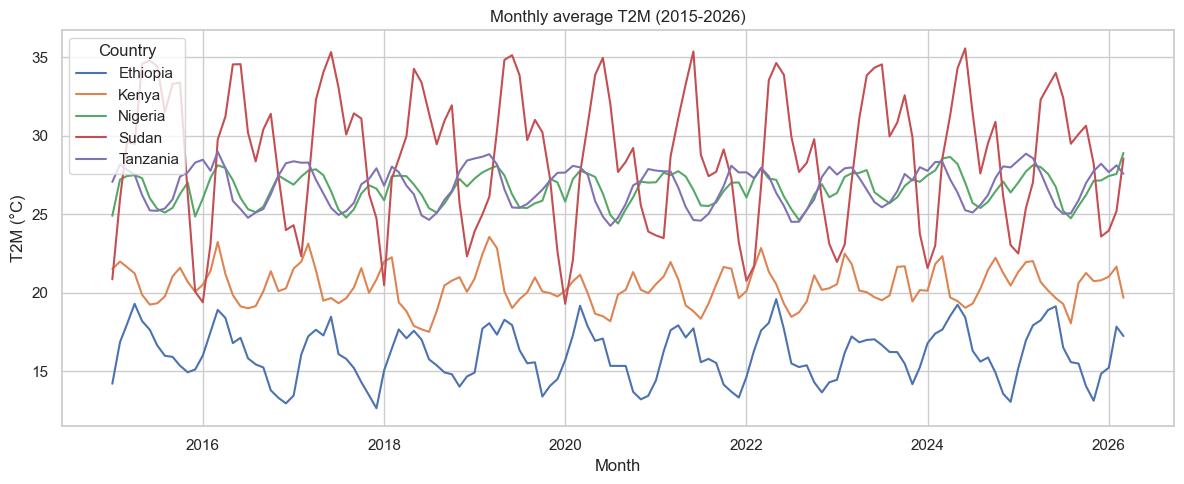

In [3]:
# Temperature Trend Comparison: monthly average T2M per country (2015-2026)
df_temp = df_all.dropna(subset=['T2M']).copy()
df_temp['month'] = df_temp['time'].dt.to_period('M').apply(lambda p: p.to_timestamp())
monthly = df_temp.groupby(['country','month'])['T2M'].mean().reset_index()
monthly = monthly[(monthly['month'].dt.year >= 2015) & (monthly['month'].dt.year <= 2026)]
pivot = monthly.pivot(index='month', columns='country', values='T2M')
plt.figure(figsize=(12,5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)
plt.legend(title='Country')
plt.title('Monthly average T2M (2015-2026)')
plt.xlabel('Month')
plt.ylabel('T2M (°C)')
plt.tight_layout()
plt.show()

In [4]:
# Summary table for T2M: mean, median, std
t2m_summary = df_all.groupby('country')['T2M'].agg(['mean','median','std']).round(2)
display(t2m_summary.reset_index())

,country,mean,median,std
0,Ethiopia,16.07,16.04,1.90
1,Kenya,20.43,20.36,1.44
2,Nigeria,26.66,26.82,1.12
3,Sudan,28.76,29.16,4.68
4,Tanzania,26.80,26.99,1.33


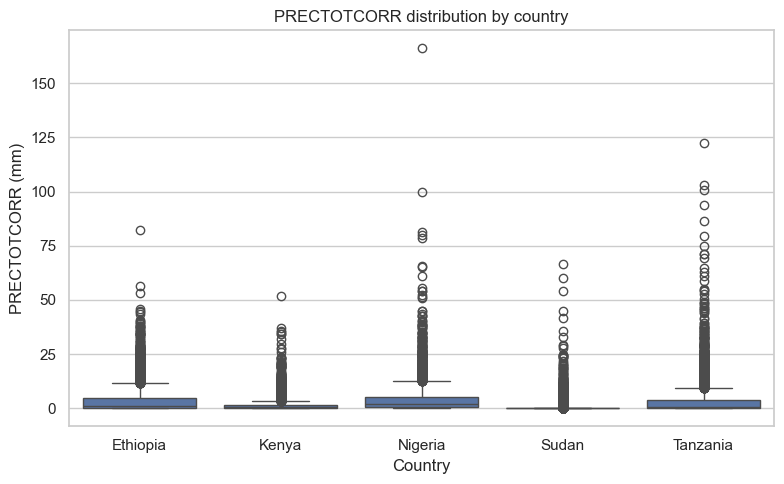

In [5]:
# Precipitation variability: boxplots of PRECTOTCORR per country
df_prec = df_all.dropna(subset=['PRECTOTCORR']).copy()
plt.figure(figsize=(8,5))
sns.boxplot(x='country', y='PRECTOTCORR', data=df_prec)
plt.title('PRECTOTCORR distribution by country')
plt.ylabel('PRECTOTCORR (mm)')
plt.xlabel('Country')
plt.tight_layout()
plt.show()

In [6]:
# Summary table for PRECTOTCORR: mean, median, std
prec_summary = df_all.groupby('country')['PRECTOTCORR'].agg(['mean','median','std']).round(2)
display(prec_summary.reset_index())

,country,mean,median,std
0,Ethiopia,3.63,0.82,6.29
1,Kenya,1.47,0.38,3.18
2,Nigeria,4.21,1.84,7.27
3,Sudan,0.64,0.00,3.06
4,Tanzania,3.74,0.64,8.00


,country,mean_annual_hot_days,mean_annual_max_consec_dry_days
0,Ethiopia,0.0,37.9
1,Kenya,0.0,41.1
2,Nigeria,0.0,35.8
3,Sudan,224.5,142.8
4,Tanzania,0.0,40.2


C:\Users\nuha.DESKTOP-3PA64PA\AppData\Local\Temp\ipykernel_5940\1524481656.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extreme_table, x='country', y='mean_annual_hot_days', palette='muted')


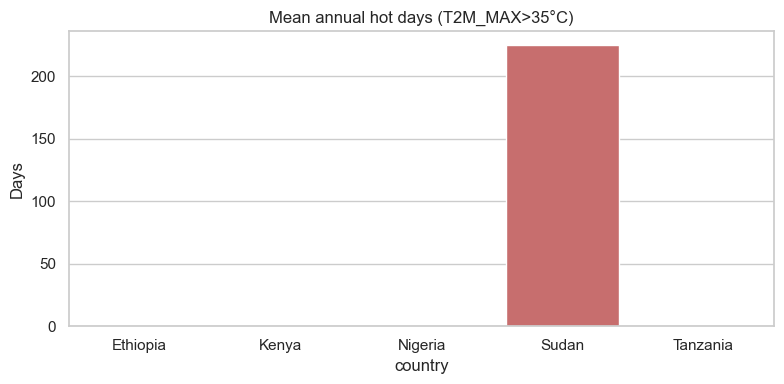

C:\Users\nuha.DESKTOP-3PA64PA\AppData\Local\Temp\ipykernel_5940\1524481656.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extreme_table, x='country', y='mean_annual_max_consec_dry_days', palette='rocket')


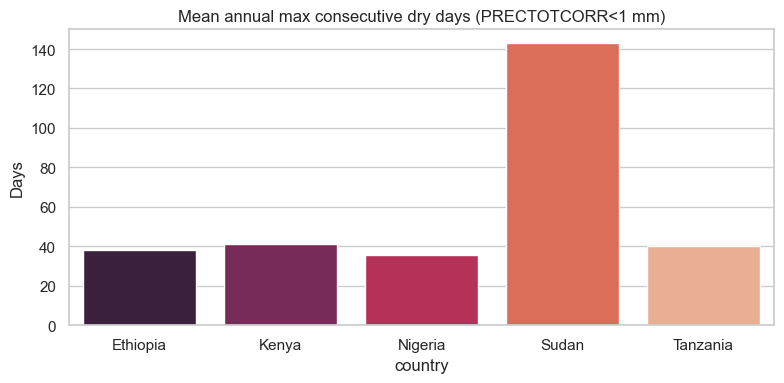

In [7]:
# Extreme events: hot days (T2M_MAX>35C fallback to T2M) and consecutive dry days (PRECTOTCORR<1 mm)
df_e = df_all.copy()
temp_col = 'T2M_MAX' if 'T2M_MAX' in df_e.columns else 'T2M'
df_e['hot'] = df_e[temp_col] > 35
df_e['year'] = df_e['time'].dt.year
hot_counts = df_e.groupby(['country','year'])['hot'].sum().reset_index().groupby('country')['hot'].mean().round(1).rename('mean_annual_hot_days')
def max_consec_dry(s):
    dry = (s < 1).astype(int).values
    if len(dry)==0:
        return np.nan
    max_run = 0
    cur = 0
    for v in dry:
        if v==1:
            cur += 1
            if cur>max_run: max_run=cur
        else:
            cur = 0
    return max_run
cdd_list = []
for (c, y), g in df_e.groupby(['country','year']):
    maxc = max_consec_dry(g.sort_values('time')['PRECTOTCORR'].fillna(0))
    cdd_list.append({'country': c, 'year': y, 'max_consec_dry': maxc})
cdd_df = pd.DataFrame(cdd_list)
cdd_mean = cdd_df.groupby('country')['max_consec_dry'].mean().round(1).rename('mean_annual_max_consec_dry_days')
extreme_table = pd.concat([hot_counts, cdd_mean], axis=1).reset_index()
display(extreme_table)
plt.figure(figsize=(8,4))
sns.barplot(data=extreme_table, x='country', y='mean_annual_hot_days', palette='muted')
plt.title('Mean annual hot days (T2M_MAX>35°C)')
plt.ylabel('Days')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,4))
sns.barplot(data=extreme_table, x='country', y='mean_annual_max_consec_dry_days', palette='rocket')
plt.title('Mean annual max consecutive dry days (PRECTOTCORR<1 mm)')
plt.ylabel('Days')
plt.tight_layout()
plt.show()

In [8]:
# Statistical testing on T2M across countries: ANOVA and Kruskal-Wallis
groups = [g['T2M'].dropna().values for _, g in df_all.groupby('country')]
non_empty = [g for g in groups if len(g)>0]
if len(non_empty) < 2:
    print('Not enough data for statistical tests')
else:
    try:
        fstat, p_anova = stats.f_oneway(*non_empty)
    except Exception:
        fstat, p_anova = (np.nan, np.nan)
    try:
        hstat, p_kruskal = stats.kruskal(*non_empty)
    except Exception:
        hstat, p_kruskal = (np.nan, np.nan)
    print(f'ANOVA p-value: {p_anova:.4g}')
    print(f'Kruskal-Wallis p-value: {p_kruskal:.4g}')

ANOVA p-value: 0
Kruskal-Wallis p-value: 0


In [9]:
# Vulnerability ranking: compute metrics and composite score
ann = df_all.set_index('time').groupby('country').resample('YE')['T2M'].mean().reset_index()
slopes = {}
for c, g in ann.groupby('country'):
    g = g.dropna(subset=['T2M'])
    if len(g) >= 2:
        x = (g['time'].dt.year - g['time'].dt.year.min()).values
        y = g['T2M'].values
        try:
            slope = np.polyfit(x, y, 1)[0]
        except Exception:
            slope = np.nan
    else:
        slope = np.nan
    slopes[c] = slope
slope_series = pd.Series(slopes).rename('warming_slope_degC_per_year')
prec_monthly = df_all.dropna(subset=['PRECTOTCORR']).copy()
prec_monthly['month'] = prec_monthly['time'].dt.to_period('M').apply(lambda p: p.to_timestamp())
prec_var = prec_monthly.groupby(['country','month'])['PRECTOTCORR'].sum().reset_index().groupby('country')['PRECTOTCORR'].std().rename('precip_monthly_std')
metrics = pd.concat([slope_series, prec_var, hot_counts, cdd_mean], axis=1)
metrics = metrics.rename_axis('country').reset_index()
norm = metrics.copy()
for col in ['warming_slope_degC_per_year','precip_monthly_std','mean_annual_hot_days','mean_annual_max_consec_dry_days']:
    if col not in norm.columns:
        norm[col+'_norm'] = np.nan
        continue
    vals = norm[col].astype(float)
    if vals.notna().sum() == 0:
        norm[col + '_norm'] = np.nan
    else:
        mn, mx = vals.min(), vals.max()
        if pd.isna(mn) or pd.isna(mx) or mx==mn:
            norm[col + '_norm'] = 0.0
        else:
            norm[col + '_norm'] = (vals - mn) / (mx - mn)
norm['composite_score'] = norm[[c + '_norm' for c in ['warming_slope_degC_per_year','precip_monthly_std','mean_annual_hot_days','mean_annual_max_consec_dry_days']]].mean(axis=1)
norm['rank'] = norm['composite_score'].rank(ascending=False, method='min').astype('Int64')
rank_df = norm.sort_values('rank').reset_index(drop=True)
display(rank_df[['country','composite_score','rank'] + [c + '_norm' for c in ['warming_slope_degC_per_year','precip_monthly_std','mean_annual_hot_days','mean_annual_max_consec_dry_days']]])

,country,composite_score,rank,warming_slope_degC_per_year_norm,precip_monthly_std_norm,mean_annual_hot_days_norm,mean_annual_max_consec_dry_days_norm
0,Sudan,0.500000,1,0.000000,0.000000,1.0,1.000000
1,Tanzania,0.459687,2,0.833788,0.963839,0.0,0.041121
2,Ethiopia,0.457536,3,0.810516,1.000000,0.0,0.019626
3,Nigeria,0.449590,4,1.000000,0.798358,0.0,0.000000
4,Kenya,0.201634,5,0.694237,0.062768,0.0,0.049533


In [10]:
# COP32 bullets: populate from rank_df and display as Markdown
top = rank_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
def best_country(col_norm):
    if col_norm in rank_df.columns and rank_df[col_norm].notna().any():
        return rank_df.loc[rank_df[col_norm].idxmax(), 'country']
    return top.loc[0, 'country']
fastest = best_country('warming_slope_degC_per_year_norm')
most_precip_var = best_country('precip_monthly_std_norm')
most_heat = best_country('mean_annual_hot_days_norm')
most_drought = best_country('mean_annual_max_consec_dry_days_norm')
def get_metric(country, col):
    try:
        val = rank_df.loc[rank_df['country']==country, col].values[0]
        return None if pd.isna(val) else float(val)
    except Exception:
        return None
fastest_val = get_metric(fastest, 'warming_slope_degC_per_year')
precip_val = get_metric(most_precip_var, 'precip_monthly_std')
heat_val = get_metric(most_heat, 'mean_annual_hot_days')
drought_val = get_metric(most_drought, 'mean_annual_max_consec_dry_days')
eth = rank_df[rank_df['country'].str.lower() == 'ethiopia']
if len(eth):
    eth_row = eth.iloc[0].to_dict()
    eth_rank = int(eth_row.get('rank', 0)) if not pd.isna(eth_row.get('rank', np.nan)) else None
    eth_score = float(eth_row.get('composite_score')) if not pd.isna(eth_row.get('composite_score', np.nan)) else None
else:
    eth_row = None
    eth_rank = None
    eth_score = None
top_country = top.iloc[0]['country'] if len(top) else 'n/a'
top_score = float(top.iloc[0]['composite_score']) if len(top) and not pd.isna(top.iloc[0]['composite_score']) else None
bullet_lines = [
    (f'* **Warming fastest:** {fastest} (slope = {fastest_val:.3f} °C/year)') if fastest_val is not None else f'* **Warming fastest:** {fastest} (slope = n/a)',
    (f'* **Precipitation instability:** {most_precip_var} (monthly std = {precip_val:.2f} mm)') if precip_val is not None else f'* **Precipitation instability:** {most_precip_var} (value n/a)',
    (f'* **Extreme heat & drought burden:** {most_heat} (mean annual hot days = {heat_val:.1f}) and {most_drought} (mean max consecutive dry days = {drought_val:.1f})') if (heat_val is not None and drought_val is not None) else f'* **Extreme heat & drought burden:** {most_heat} / {most_drought} (values n/a)',
    (f'* **Ethiopia compared to neighbors:** Ethiopia ranks {eth_rank} with composite score {eth_score:.3f}') if eth_row is not None and eth_rank is not None else '* **Ethiopia compared to neighbors:** Ethiopia data not present.',
    (f'* **Policy ask for COP32:** Prioritize climate finance for {top_country} — highest composite vulnerability (score = {top_score:.3f}).') if top_score is not None else f'* **Policy ask for COP32:** Prioritize climate finance for {top_country} (score n/a)',
]
md = '# COP32 Key Observations\n' + '\n'.join(bullet_lines)
display(Markdown(md))

# COP32 Key Observations
* **Warming fastest:** Nigeria (slope = 0.087 °C/year)
* **Precipitation instability:** Ethiopia (monthly std = 114.20 mm)
* **Extreme heat & drought burden:** Sudan (mean annual hot days = 224.5) and Sudan (mean max consecutive dry days = 142.8)
* **Ethiopia compared to neighbors:** Ethiopia ranks 3 with composite score 0.458
* **Policy ask for COP32:** Prioritize climate finance for Sudan — highest composite vulnerability (score = 0.500).

---
Notes: run all cells to ensure `rank_df` and bullets are populated. If files are missing, the notebook will print warnings.